In [1]:
# Setup: importa bibliotecas e garante que `src/` esteja no path
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Define caminhos relativos (assume que este notebook está em /notebooks)
notebook_path = Path.cwd()
project_root = notebook_path.parent if (notebook_path / '..').exists() else notebook_path
src_path = project_root / 'src'
sys.path.insert(0, str(src_path))
print(f'Usando src: {src_path}')

# Importa módulos do projeto
try:
    from fits_reader import FITSReader, load_fits
    from image_processor import ImageProcessor
    from rgb_converter import RGBConverter
    from pipeline import AstroDataVizPipeline
    print('✅ Imports do projeto carregados com sucesso')
except Exception as e:
    print('❌ Erro ao importar módulos do projeto:', e)
    print('Verifique se você está executando este notebook a partir da pasta `notebooks/` e se instalou as dependências (pip install -r ../requirements.txt)')

Usando src: c:\Users\erikc\OneDrive\Documentos\astro-data-viz-python\astro-data-viz-python\src
✅ Imports do projeto carregados com sucesso


In [2]:
# Lista arquivos FITS em ./data/raw
fits_dir = project_root / 'data' / 'raw'
fits = sorted(fits_dir.glob('*.fits')) if fits_dir.exists() else []
print(f'Pasta: {fits_dir}')
print(f'Encontrados {len(fits)} arquivos FITS')
for f in fits:
    print(' -', f.name)

Pasta: c:\Users\erikc\OneDrive\Documentos\astro-data-viz-python\astro-data-viz-python\data\raw
Encontrados 7 arquivos FITS
 - synthetic_band_blue.fits
 - synthetic_band_green.fits
 - synthetic_band_infrared.fits
 - synthetic_band_red.fits
 - synthetic_band_ultraviolet.fits
 - synthetic_monochrome.fits
 - synthetic_multiband.fits


In [3]:
# Carrega um FITS de exemplo (o primeiro encontrado ou o sintético multi-band)
if fits:
    fits_path = fits[0]
else:
    fits_path = project_root / 'data' / 'raw' / 'synthetic_multiband.fits'

print('Usando:', fits_path)

with FITSReader(str(fits_path)) as reader:
    print(reader.get_info())
    all_data = reader.get_all_data()

print('Bandas carregadas:', list(all_data.keys()))

INFO:fits_reader:Arquivo FITS carregado: c:\Users\erikc\OneDrive\Documentos\astro-data-viz-python\astro-data-viz-python\data\raw\synthetic_band_blue.fits


Usando: c:\Users\erikc\OneDrive\Documentos\astro-data-viz-python\astro-data-viz-python\data\raw\synthetic_band_blue.fits
Arquivo: synthetic_band_blue.fits
Número de HDUs: 1

HDU 0: PRIMARY
  Shape: (512, 512)
  Data type: >f4
  Min: 1.93e+01, Max: 1.11e+03
Bandas carregadas: ['hdu_0_PRIMARY']


Primeira banda: hdu_0_PRIMARY  |  shape: (512, 512)  | dtype: >f4


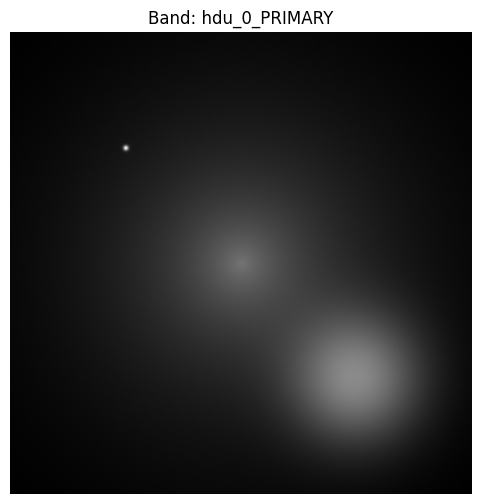

In [4]:
# Visualiza a primeira banda carregada
first_name, first_data = next(iter(all_data.items()))
print(f'Primeira banda: {first_name}  |  shape: {first_data.shape}  | dtype: {first_data.dtype}')
plt.figure(figsize=(6,6))
plt.imshow(first_data, cmap='gray')
plt.title(f'Band: {first_name}')
plt.axis('off')
plt.show()

INFO:image_processor:Iniciando pipeline de processamento...
INFO:image_processor:NaN tratado
INFO:image_processor:Normalizado (percentile)
INFO:image_processor:Stretching aplicado (asinh)
INFO:image_processor:Contraste realçado
INFO:image_processor:Suavização aplicada (kernel=3)
INFO:image_processor:Pipeline concluído!


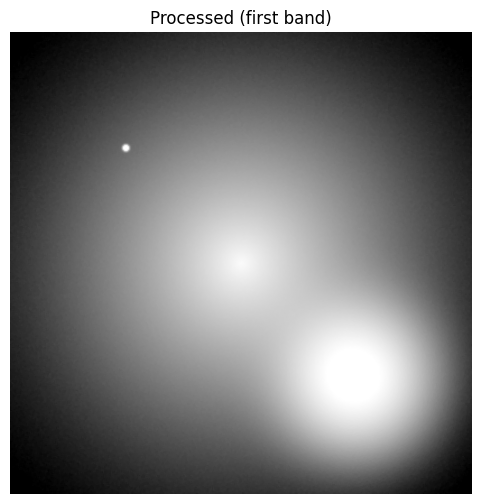

In [5]:
# Aplica pipeline simples (normalize + asinh) na primeira banda
processed = ImageProcessor.apply_pipeline(first_data, normalize_method='percentile', stretch_method='asinh', enhance=True, smooth_kernel=3)
plt.figure(figsize=(6,6))
plt.imshow(processed, cmap='gray')
plt.title('Processed (first band)')
plt.axis('off')
plt.show()

In [6]:
# Se houver pelo menos 3 bandas, combina como RGB
bands = list(all_data.items())[:3]
if len(bands) < 3:
    print('Menos de 3 bandas encontradas — não é possível combinar em RGB automaticamente')
else:
    channels = []
    for name, data in bands:
        ch = ImageProcessor.apply_pipeline(data, normalize_method='percentile', stretch_method='asinh', enhance=True, smooth_kernel=3)
        channels.append(ch)
    rgb = RGBConverter.combine_channels(channels[0], channels[1], channels[2])
    plt.figure(figsize=(8,5))
    plt.imshow(rgb)
    plt.title('Combined RGB (first 3 bands)')
    plt.axis('off')
    plt.show()

Menos de 3 bandas encontradas — não é possível combinar em RGB automaticamente


In [7]:
# Salva a imagem RGB em ./data/processed/play_demo.png (se criada)
try:
    output_dir = project_root / 'data' / 'processed'
    output_dir.mkdir(parents=True, exist_ok=True)
    pipeline = AstroDataVizPipeline(str(output_dir))
    output_path = output_dir / 'play_demo.png'
    if 'rgb' in globals():
        pipeline._save_rgb_image(rgb, str(output_path))
        print('✅ Salvo em:', output_path)
    else:
        print('Nenhuma imagem RGB foi gerada nesta sessão — combine 3 bandas primeiro')
except Exception as e:
    print('Erro ao salvar imagem:', e)

Nenhuma imagem RGB foi gerada nesta sessão — combine 3 bandas primeiro


## Baixar mais dados do MAST
Se quiser obter dados reais (Hubble / JWST) direto do MAST, execute o script de download a partir da raiz do projeto. Exemplos de uso: `python download_mast_data.py --target "M51" --limit 1 --process`.
No notebook você pode executar isso em uma célula com `!python ../download_mast_data.py --target "M51" --limit 1 --process` (remova o `!` se preferir usar `subprocess`).

Depois de baixar, volte a célula de listagem para ver os novos FITS em `./data/raw` e repetir o processamento.